# Assessing 20mph Policy Impact and Risk Factors in London Traffic Accidents: A Machine Learning and Difference-in-Differences Analysis
## CASA0006: Data Science for Spatial Systems
## Student ID: 24054679

## Preparation

- [Github link](https://github.com/Aurora-77777/casa0006) 

- Number of words: 1632

- Runtime: 4 mins (*Memory 10 GB, CPU Intel i7-10700 CPU @2.90GHz*)

- Coding environment: SDS Docker (or anything else)

- License: this notebook is made available under the [Creative Commons Attribution license](https://creativecommons.org/licenses/by/4.0/) (or other license that you like).

In [48]:
import json
import re

# 读取notebook
with open('Template_submission_CASA0006.ipynb', 'r') as f:
    content = f.read()

notebook = json.loads(content)
markdown_text = ""

for cell in notebook['cells']:
    if cell['cell_type'] == 'markdown':
        # 只提取markdown cell中的文本
        cell_text = " ".join(cell['source'])
        # 移除markdown格式符号
        cell_text = re.sub(r'[#*`\[\]()]', '', cell_text)
        # 移除代码块标记
        cell_text = re.sub(r'```.*?```', '', cell_text, flags=re.DOTALL)
        markdown_text += cell_text + " "

# 计算纯文本字数
words = len(markdown_text.split())
print(f"Analysis text word count: {words}")
print(f"Remaining words to 1500 limit: {1500 - words}")

# 显示前200字符预览
print(f"\nText preview:\n{markdown_text[:200]}...")

Analysis text word count: 3212
Remaining words to 1500 limit: -1712

Text preview:
 Assessing 20mph Policy Impact and Risk Factors in London Traffic Accidents: A Machine Learning and Difference-in-Differences Analysis
  CASA0006: Data Science for Spatial Systems
  Student ID: 240546...


## Table of contents

[Introduction](#Introduction)

[Literature review](#Literature-review)

[Research questions](#Research-questions)

[Data](#Data)

[Methodology](#Methodology)

[Results and discussion](#Results-and-discussion)

[Conclusion](#Conclusion)

[References](#References)

## 1.Introduction

[[ go back to the top ]](#Table-of-contents)

Traffic remains a innegligible issue around the world. In Great British, there were totally 135,480 Road casualties in 2022 (Department for Transport, 2023), with London being one of the most affected metropolitan areas.  Previous studies highlight that environmental factors such as job density and traffic flow (Xiao, D., et al., 2024). Besides objective factors, human subjective factors like gender or drive period also makes a big difference on accident severity (Massie, D. L.,1993 , Cullen, P., 2021). Therefore, researching the different dimension factors in traffic accident severit is meaningful, especially for london which didn't have solid research yet. Furthermore, former researches also take policy's influence into account and show significant outcome (Prieto-Rodriguez, J. et al., 2022, Ellison, R. B., et al.,2013). In that case, empirical studies on policy interventions are also a strong factor which may cause variability in the data.

Based on former researches, I tend to use DID to find the inner policy effect and set the potential policy confounding effects aside to use Machine Learning to explore environment, human/vehicle characters and other indictors' function on accident severity.

## 2.Literature review

[[ go back to the top ]](#Table-of-contents)

A growing amount of literatures analysed multiple factors influencing accident severity, extremely demographic and environmental factors. Environmental conditions such as traffic flow, job density, and road surface play a significant role in shaping crash outcomes(Phan, 2024, Xiao, D., et al., 2024). Regev et al., (2018) shows that both young and old driver (called as extreme age driver) have higher crash risks(Regev et al., 2018). Lee, et al., (2023) further confirmed that driver's age amd gender make a big different on driving behaving with high crash severity degree （Lee,2023）. 

In methodology aspect, Obasi (2023) compared several classifiers on UK data and put ehicle age, driver age, and daytime as critical predictors.(Obasi, 2023) and Sufian (2024) integrated ML, econometric models and time series forecasting, using SHAP to enhence interpretability afterwards (Sufian,2024).

However, applications combining causal inference tools such as Difference-in-Difference with Machine Learning remain rare especially in London, with most tradtional econometric models dominating accident severity studies. My study tends to address this gap.

## 3.Research questions

[[ go back to the top ]](#Table-of-contents)

To what extent do environmental, human, vehicle, and policy-related factors contribute to the severity of traffic accidents in London, and how can the combination of Difference-in-Differences (DID) and Machine Learning methods effectively uncover causal impacts and predictive patterns?

The specific research objectives are:

1. **Looking Into Main Factors**: There is a need to study how things like job numbers in one area (environmental activity), time when accidents happen (time factor), and vehicle/human features (subjective factors) make the accident worse or not.  

2. **Policy Influence Controlling**: Things that can confuse the observation like the policy which may cause a big effect on the severity of accidents. Considering this, I prone to take policy effect inside and look through the infuence.

3. **Suggestions Developing**: It would be helpful to write down certain practical things,such as where traffic should be slowed with calming systems, or some rules changed for vehicles—that can help make severe accidents fewer. These suggestions should be based on the locations and patterns seen, and what risks were found.

## 4.Data Description

[[ go back to the top ]](#Table-of-contents)


The notebook is an exploration of time-based trends in 2023 seen in [London traffic accident][1] dataset. 

|dataset|dimension|description|
|---|---|---|
|[London traffic accidents][1]|Website to see related details|Overviwe on Road safety|
|[London casualties Accidents][2]|LSOA|People who get crashed or accidents|
|[London Traffic Vehicles][3]|LSOA|Vehicle details which had accidents at the road|
|[London Traffic collisions][4]|LSOA|Details about traffic collisions|
|[London borough geography][5]|LSOA Geojson|Geography information on LSOA|
|[London job density][6]|LSOA|Job density in every boroughs|
|[20mph policy details][7]|ROAD|Detailed instructures on restrict speed policy|

The time detailed to the minute.
|feature|description|
|---|---|
|Date|formatted as DD/MM/YYYY|
|Time|formatted as HH:MM|
|Year|YYYY|
|Day_of_Week|1=Sun, 2=Mon, 3=Tue, 4=Wed, 5=Thu, 6=Fri, 7=Sat|

The combined dataset by LSOA code has 23 features describing each of the accidents recorded therein, where the attributes included describe things like
* the date and time of the accident
* the physical location of the accident
* the current weather conditions
* the severity of the accident
* the job density of research dimensions

From this research, I am going to focus on whether policy effect the severity of jobs, and what kind of indicators effect.


[1]:https://www.data.gov.uk/dataset/cb7ae6f0-4be6-4935-9277-47e5ce24a11f/road-accidents-safety-data
[2]:https://data.dft.gov.uk/road-accidents-safety-data/dft-road-casualty-statistics-casualty-2023.csv
[3]:https://data.dft.gov.uk/road-accidents-safety-data/dft-road-casualty-statistics-vehicle-2023.csv
[4]:https://data.dft.gov.uk/road-accidents-safety-data/dft-road-casualty-statistics-collision-2023.csv
[5]:https://raw.githubusercontent.com/Aurora-77777/casa0006/main/data/Boroughs.gpkg
[6]:https://data.london.gov.uk/download/jobs-and-job-density-borough/116a2961-6c12-4960-ab3a-945c7448a989/jobs-and-job-density.xlsx
[7]:https://raw.githubusercontent.com/Aurora-77777/casa0006/main/20-mph-zones-and-road-safety-in-london.pdf

| Variable Name | Type | Description | Values/Range |
|---------------|------|-------------|--------------|
| **Target Variable** |
| `severity_code` | Binary | Accident severity classification | 0 = Slight, 1 = Severe |
| **Numeric Features** |
| `age_of_vehicle` | Continuous | Age of vehicle involved in accident | Years |
| `job_density` | Continuous | Job density in the area (LSOA level) | Jobs per unit area |
| `vehicles_rate` | Continuous | Number of vehicles per accident | Count |
| `casualties_rate` | Continuous | Number of casualties per accident | Count |
| **Categorical Features** |
| `weather_conditions_category` | Categorical | Weather conditions during accident | Fine, Rain, Snow, etc. |
| `road_surface_conditions_category` | Categorical | Road surface condition | Dry, Wet, Snow, etc. |
| `day_of_week_category` | Categorical | Day of the week | Monday, Tuesday, etc. |
| `casualty_type_category` | Categorical | Type of casualty | Car, Pedestrian, etc. |
| `sex_of_driver_category` | Categorical | Gender of driver | Male, Female |
| `rush_hour` | Binary | Rush hour indicator | Non-rush, Rush (7-9am, 4-7pm) |
| `extreme_age` | Binary | Extreme age driver indicator | Normal_age, Extreme_age (≤25 or ≥65) |
| **Policy Variables** |
| `treat` | Binary | Treatment group indicator | 0 = Control, 1 = Treatment |
| `post` | Binary | Post-policy period indicator | 0 = Pre-policy, 1 = Post-policy |
| `did` | Binary | Difference-in-differences interaction | treat × post |

### 4.1 Data Introduction

In [1]:
#pip install linearmodels

In [2]:
# All the packages used below have been downloaded already under this environment 
#if any package is missing please use the pip install command to install it. For example pip install pandas.
import pandas as pd
import geopandas as gpd
import numpy as np
import requests # for loading data from websites remotely
import contextily
from shapely.geometry import Point
from io import BytesIO, StringIO # deal with different file catelogies (csv or excel)
from scipy import stats # for descriptive statistics
from scipy.stats import zscore
import warnings # suppress the warning
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, RocCurveDisplay)
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
from math import pi

#!pip install linearmodels
import plotly
import shap
import plotly.express as px
from statsmodels.formula.api import ols
from statsmodels.iolib.summary2 import summary_col
from linearmodels import PanelOLS
from linearmodels import RandomEffects
import statsmodels.formula.api as smf
from linearmodels.panel import compare
from libpysal.weights import DistanceBand
from spglm.family import Binomial

warnings.filterwarnings('ignore')
sns.set(font_scale=1.5)
sns.set_style("white")
plt.rcParams['figure.figsize'] = (12, 8)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### 4.1.1 Loading the Data

In [3]:
# function for loading the datasets file_format can be:'csv'/'excel'/'geopackage' (or 'gpkg') for geospatial data

def load_data(remote_url, local_path, file_format="csv", **kwargs):
    try:
        print(f"Attempting to load data from {remote_url} (format={file_format})")
        response = requests.get(remote_url)
        response.raise_for_status()
        if file_format.lower() in ["excel", "xlsx", "xls"]:
            # Read Excel from in-memory bytes
            return pd.read_excel(BytesIO(response.content), **kwargs)

        elif file_format.lower() in ["geopackage", "gpkg"]:
            raise ValueError(
                "Direct remote reading of GPKG is not straightforward. "
                "Falling back to local file."
            )

        else:
            csv_text = response.text
            return pd.read_csv(StringIO(csv_text), **kwargs)

    except Exception as e:
        print(f"Failed to load from remote URL: {e}\nReading local file instead...")
    # If remote attempt fails, load from local_path:
    if file_format.lower() in ["excel", "xlsx", "xls"]:
        return pd.read_excel(local_path, **kwargs)
    elif file_format.lower() in ["geopackage", "gpkg"]:
        return gpd.read_file(local_path)
    else:
        return pd.read_csv(local_path, **kwargs)

##### 4.1.1.1. Road safety data

In [4]:
# URLs for the remote files on GitHub
url_casualties = 'https://data.dft.gov.uk/road-accidents-safety-data/dft-road-casualty-statistics-casualty-2023.csv'
url_collisions = 'https://data.dft.gov.uk/road-accidents-safety-data/dft-road-casualty-statistics-collision-2023.csv'
url_vehicles = 'https://data.dft.gov.uk/road-accidents-safety-data/dft-road-casualty-statistics-vehicle-2023.csv'
url_ward='https://raw.githubusercontent.com/Aurora-77777/casa0006/main/data/Boroughs.gpkg'

# Paths to the local files while we assume that the parent directory has been assigned to the current working directory already and the datasets are in the data folder under the directory
local_casualties = 'data/casualty.csv'
local_collisions = 'data/collision.csv'
local_vehicles = 'data/vehicle.csv'
local_ward='data/Boroughs.gpkg'

In [5]:
# load the dataset
collisions = load_data(url_collisions, local_collisions, encoding="utf-8-sig",file_format="csv")
casualties = load_data(url_casualties, local_casualties, encoding="utf-8-sig",file_format="csv")
vehicles = load_data(url_vehicles, local_vehicles, encoding="utf-8-sig",file_format="csv")
# load the geopackages of London
ward= load_data(url_ward, local_ward, file_format="gpkg")

dataframes = [collisions, casualties, vehicles]

for df in dataframes:
    df.rename(columns={"ï»¿accident_index": "accident_index"}, inplace=True)

Attempting to load data from https://data.dft.gov.uk/road-accidents-safety-data/dft-road-casualty-statistics-collision-2023.csv (format=csv)
Attempting to load data from https://data.dft.gov.uk/road-accidents-safety-data/dft-road-casualty-statistics-casualty-2023.csv (format=csv)
Attempting to load data from https://data.dft.gov.uk/road-accidents-safety-data/dft-road-casualty-statistics-vehicle-2023.csv (format=csv)
Attempting to load data from https://raw.githubusercontent.com/Aurora-77777/casa0006/main/data/Boroughs.gpkg (format=gpkg)
Failed to load from remote URL: 404 Client Error: Not Found for url: https://raw.githubusercontent.com/Aurora-77777/casa0006/main/data/Boroughs.gpkg
Reading local file instead...


In [6]:
# Check for null values in the key columns
print(collisions['accident_index'].isnull().sum())
print(casualties['accident_index'].isnull().sum())
print(vehicles['accident_index'].isnull().sum())

# Check data types
print(collisions['accident_index'].dtype)
print(casualties['accident_index'].dtype)
print(vehicles['accident_index'].dtype)

0
0
0
object
object
object


##### 4.1.1.2. Job density data

In [7]:
url_job = "https://data.london.gov.uk/download/jobs-and-job-density-borough/116a2961-6c12-4960-ab3a-945c7448a989/jobs-and-job-density.xlsx"
local_job = "data/jobs.csv"
job = load_data(url_job, local_job, file_format="excel", sheet_name="Jobs Density")

Attempting to load data from https://data.london.gov.uk/download/jobs-and-job-density-borough/116a2961-6c12-4960-ab3a-945c7448a989/jobs-and-job-density.xlsx (format=excel)


Transfer all(2000-2023 columns) to one column named year,and all these years become rows.

In [8]:
df_long = pd.melt(
    job,
    id_vars=["Code", "Area"],         # the columns to keep fixed
    var_name="Year",                  # the new column name for melted column headers
    value_name="Job density"  # name for the values in the melted column
)

# Optionally, convert the 'Year' column to integer:
df_long["Year"] = df_long["Year"].astype(int)

job = df_long.dropna(subset=["Code", "Area"])

In [9]:
job.head()

,Code,Area,Year,Job density
1,E09000001,City of London,2000,67.1
2,E09000002,Barking and Dagenham,2000,0.56
3,E09000003,Barnet,2000,0.67
4,E09000004,Bexley,2000,0.55
5,E09000005,Brent,2000,0.67


### 4.1.2 Merging Dataframe

In [10]:
# Merging collisions/vehicles with casualties using accdient index
merged_data = pd.merge(collisions, casualties, on='accident_index', how='inner')
merged_data2 = pd.merge(merged_data, vehicles, on='accident_index', how='inner')

In [11]:
#Merging Job density with already merged data by combining local authority code and year
merged_data3 = merged_data2.merge(
    job,
    left_on=['local_authority_ons_district', 'accident_year'],
    right_on=['Code', 'Year'],
    how='inner'
)

In [12]:
merged_data3["Code"].unique()

array(['E09000024', 'E09000010', 'E09000017', 'E09000003', 'E09000032',
       'E09000007', 'E09000028', 'E09000025', 'E09000014', 'E09000018',
       'E09000012', 'E09000019', 'E09000026', 'E09000031', 'E09000022',
       'E09000023', 'E09000033', 'E09000005', 'E09000020', 'E09000004',
       'E09000009', 'E09000016', 'E09000002', 'E09000030', 'E09000015',
       'E09000008', 'E09000027', 'E09000029', 'E09000013', 'E09000021',
       'E09000006', 'E09000011'], dtype=object)

In [13]:
merged_data3.head()

,accident_index,accident_year_x,accident_reference_x,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,accident_severity,number_of_vehicles,...,escooter_flag,dir_from_e,dir_from_n,dir_to_e,dir_to_n,driver_distance_banding,Code,Area,Year,Job density
0,2023010419171,2023,10419171,525060.0,170416.0,-0.202878,51.418974,1,3,1,...,0,NaN,NaN,NaN,NaN,2,E09000024,Merton,2023,0.73
1,2023010419183,2023,10419183,535463.0,198745.0,-0.042464,51.671155,1,3,3,...,0,NaN,NaN,NaN,NaN,2,E09000010,Enfield,2023,0.63
2,2023010419183,2023,10419183,535463.0,198745.0,-0.042464,51.671155,1,3,3,...,0,NaN,NaN,NaN,NaN,1,E09000010,Enfield,2023,0.63
3,2023010419183,2023,10419183,535463.0,198745.0,-0.042464,51.671155,1,3,3,...,0,NaN,NaN,NaN,NaN,4,E09000010,Enfield,2023,0.63
4,2023010419183,2023,10419183,535463.0,198745.0,-0.042464,51.671155,1,3,3,...,0,NaN,NaN,NaN,NaN,2,E09000010,Enfield,2023,0.63


**combine shapefile with CSV**

In [14]:
#merge the new accdient data with ward data using the borough code
final_merged_data = ward.merge(merged_data3, left_on='GSS_CODE', right_on='Code',how="inner")

### 4.1.3 Data pre-processing

When preparing integrated datasets for analysis, it becomes necessary to consult [the original data guide documentation](https://www.gov.uk/government/publications/guide-to-contributory-factors-for-reported-road-casualty-statistics/guide-to-contributory-factors-for-reported-road-casualties-great-britain) to understand data characteristics. The data preparation workflow involves multiple stages listed as follows:  
1. Through transformation processes, derive temporal features from date/time columns, such as seasonal patterns  
2. Convert categorical severity codes into descriptive labels that is to say replacing numerical codes with text explanations  
3. Handle incomplete entries by marking blank fields as missing values, then calculate completeness rates across different data categories  
4. Eliminate problematic features including those with substantial missing data (over 40% incomplete), low correlation with outcomes, or overlapping characteristics with existing features  
5. Apply uniform placeholder markers (-1 or '-1') to remaining gaps while creating new indicators showing where information was incomplete, which helps track data quality issues  
6. Conduct final verification of all feature types, adjusting data formats when necessary to ensure consistency 

**4.1.3.1 Data organizing**

In [15]:
#Fish variables that useful for topic analysis out.

columns = [
    'accident_severity','casualty_class','sex_of_casualty','age_of_casualty',
    'date', 'time', 'day_of_week', 'accident_year',
    'longitude', 'latitude', 'Code', 'Area', 
    'weather_conditions', 'light_conditions', 'road_surface_conditions', 
    'number_of_vehicles', 'number_of_casualties',
    'sex_of_driver','age_of_driver',
    'casualty_type', 'engine_capacity_cc', 'age_of_vehicle',
    'Job density',
    'geometry'
]
df_selected = final_merged_data[columns]

#transfer Job density column's type to numeric one 
df_selected["Job density"] = pd.to_numeric(df_selected["Job density"], errors="coerce")

Final_selected = gpd.GeoDataFrame(df_selected, geometry='geometry')

In [16]:
Final_selected.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 48149 entries, 0 to 48148
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   accident_severity        48149 non-null  int64   
 1   casualty_class           48149 non-null  int64   
 2   sex_of_casualty          48149 non-null  int64   
 3   age_of_casualty          48149 non-null  int64   
 4   date                     48149 non-null  object  
 5   time                     48149 non-null  object  
 6   day_of_week              48149 non-null  int64   
 7   accident_year            48149 non-null  int64   
 8   longitude                48149 non-null  float64 
 9   latitude                 48149 non-null  float64 
 10  Code                     48149 non-null  object  
 11  Area                     48149 non-null  object  
 12  weather_conditions       48149 non-null  int64   
 13  light_conditions         48149 non-null  int64   
 14

In [17]:
# Extract hour, day, and month from existing columns
Final_selected['hour'] = (Final_selected['time']
               .str.split(':')
               .str[0]
               .astype(int))
# Split the 'date' column on '/', directly creating 'day' and 'month'
Final_selected[['day', 'month']] = (Final_selected['date']
                         .str.split('/', expand=True)
                         .iloc[:, [0, 1]]
                         .astype(int))

In [18]:
#Simplfy the classifications of casulty types to major road injuried types
reclassify_mapping = {
    0: 1,   # Pedestrian
    1: 2,   # Pedal cycle
    2: 3,   # Motorcycle <=50cc (Powered 2 Wheeler)
    3: 3,   # Motorcycle 125cc and under (Powered 2 Wheeler)
    4: 3,   # Motorcycle 125cc–500cc (Powered 2 Wheeler)
    5: 3,   # Motorcycle over 500cc (Powered 2 Wheeler)
    8: 5,   # Taxi/Private hire car occupant (Taxi)
    9: 4,   # Car occupant
    10: 6,  # Minibus (8-16 passenger seats) (Bus or Coach)
    11: 6,  # Bus or coach occupant (17+ seats) (Bus or Coach)
    18: 8,  # Tram (Other vehicle)
    19: 7,  # Van/Goods vehicle <= 3.5t (Goods vehicle)
    20: 7,  # Goods vehicle 3.5–7.5t (Goods vehicle)
    21: 7,  # Goods vehicle over 7.5t (Goods vehicle)
    22: 7,  # Goods vehicle over 7.5t (Goods vehicle)
    23: 8,  # Other vehicle occupant
    90: 8,  # Other vehicle occupant
    97: 3,  # Motorcycle unknown cc (Powered 2 Wheeler)
    98: 7,  # Goods vehicle unknown weight (Goods vehicle)
}

Final_selected['casualty_type'] = (
    Final_selected['casualty_type'].replace(reclassify_mapping)
)

In [19]:
# Transfer numbers to words that presented
severity_mapping = {
    1: 'fatal',
    2: 'serious',
    3: 'slight'
}
Final_selected['accident_severity_category'] = (Final_selected['accident_severity'].replace(severity_mapping))

casualty_mapping = {
    1:'Driver/Rider',
    2:'Passenger',
    3:'Pedestrian'
}

Final_selected['casualty_class_category'] = (Final_selected['casualty_class'].replace(casualty_mapping))

sex_mapping={
    1:'Male',
    2:'Female',
    3:'Unknown'
}

Final_selected['sex_of_casualty_category'] = (Final_selected['sex_of_casualty'].replace(sex_mapping))
Final_selected['sex_of_driver_category'] = (Final_selected['sex_of_driver'].replace(sex_mapping))

casualty_type_label_mapping = {
    1: 'Pedestrian',
    2: 'Pedal Cycle',
    3: 'Powered/Wheeler',
    4: 'Car',
    5: 'Taxi',
    6: 'Bus or Coach',
    7: 'Goods Vehicle',
    8: 'Other Vehicle',
    9: 'Private Hire'
}

Final_selected['casualty_type_category'] = (
    Final_selected['casualty_type'].replace(casualty_type_label_mapping)
)

day_of_week_mapping = {
    1: 'Sunday',
    2: 'Monday',
    3: 'Tuesday',
    4: 'Wednesday',
    5: 'Thursday',
    6: 'Friday',
    7: 'Saturday'
}

Final_selected['day_of_week_category'] = (
    Final_selected['day_of_week'].replace(day_of_week_mapping)
)

weather_mapping = {
    1: 'Fine no high winds',
    2: 'Raining no high winds',
    3: 'Snowing no high winds',
    4: 'Fine and high winds',
    5: 'Raining and high winds',
    6: 'Snowing and high winds',
    7: 'Fog or mist',
    8: 'Other',
    9:'Unknown'
}
Final_selected['weather_conditions_category'] = (
    Final_selected['weather_conditions'].replace(weather_mapping)
)

surface_mapping = {
    1:'Dry',
    2:'Wet or damp',
    3:'Snow',
    4:'Frost or ice',
    5:'deeply Flood',
    6:'Oil or diesel',
    7:'Mud',
    9:'Unknown'
}

Final_selected['road_surface_conditions_category'] = (
    Final_selected['road_surface_conditions'].replace(surface_mapping)
)

In [20]:
df = Final_selected.replace({-1: np.nan, '-1': np.nan})

In most situations, using a “rate” is preferable to a “count” because it normalizes the data by accounting for population size or scale. Accordingly, I considered the influence of traffic volumn and create **new accident rates**.

In [21]:
# Compute the total sum of the 'number_of_accidents' column
total_vehicles = df['number_of_vehicles'].sum()
total_casualties = df['number_of_casualties'].sum()
# Create a new column for the accident rate
df['vehicles_rate'] = (df['number_of_vehicles'] / total_vehicles)
df['casualties_rate'] = (df['number_of_casualties'] / total_casualties)

In [22]:
df['date'].head()

0    04/01/2023
1    06/01/2023
2    06/01/2023
3    09/01/2023
4    09/01/2023
Name: date, dtype: object

In [23]:
df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 48149 entries, 0 to 48148
Data columns (total 37 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   accident_severity                 48149 non-null  int64   
 1   casualty_class                    48149 non-null  int64   
 2   sex_of_casualty                   46195 non-null  float64 
 3   age_of_casualty                   46085 non-null  float64 
 4   date                              48149 non-null  object  
 5   time                              48149 non-null  object  
 6   day_of_week                       48149 non-null  int64   
 7   accident_year                     48149 non-null  int64   
 8   longitude                         48149 non-null  float64 
 9   latitude                          48149 non-null  float64 
 10  Code                              48149 non-null  object  
 11  Area                              48149 non-nu

**4.1.3.2 heatmap**

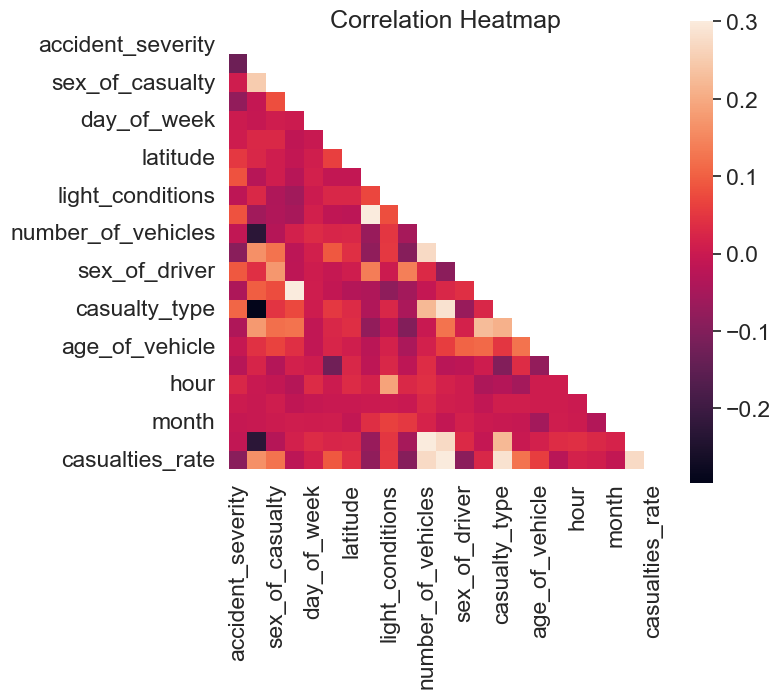

In [24]:
# To examine the correlation matrix of continuous variables
df_num = df.select_dtypes(include=[np.number])
constant_cols = df_num.columns[df_num.nunique() <= 1]
df_num.drop(columns=constant_cols, inplace=True)
corr = df_num.corr()
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
plt.figure(figsize=(7, 6))
sns.heatmap(corr, mask=mask, vmax=.3, square=True)
plt.title("Correlation Heatmap")
plt.show()

From the processed dataset, we could figure out that most features are independent. highly correlated variables are features related to casualty and vehicle conditions as well as road surface and weather.

### 4.1.4 Exploratory Data Analysis

**4.1.4.1 Descriptive Statistics for Numeric Columns**

In [25]:
df.describe()

,accident_severity,casualty_class,sex_of_casualty,age_of_casualty,day_of_week,accident_year,longitude,latitude,weather_conditions,light_conditions,...,age_of_driver,casualty_type,engine_capacity_cc,age_of_vehicle,Job density,hour,day,month,vehicles_rate,casualties_rate
count,48149.000000,48149.000000,46195.000000,46085.000000,48149.000000,48149.0,48149.000000,48149.000000,48149.000000,48149.000000,...,36769.000000,48149.000000,36198.000000,37749.000000,48149.000000,48149.000000,48149.000000,48149.000000,48149.000000,48149.000000
mean,2.842489,1.347089,1.304189,36.128024,4.158799,2023.0,-0.115992,51.509417,2.089721,2.042555,...,38.931110,3.251822,1679.768274,7.383931,1.080324,13.943093,15.839228,6.572577,0.000021,0.000021
std,0.376951,0.654028,0.460068,15.296899,1.944822,0.0,0.143818,0.070482,2.488723,1.551127,...,14.172574,1.396194,1427.435882,5.320985,1.095692,5.542206,8.692735,3.355404,0.000010,0.000014
min,1.000000,1.000000,1.000000,0.000000,1.000000,2023.0,-0.509865,51.289491,1.000000,1.000000,...,2.000000,1.000000,25.000000,0.000000,0.430000,0.000000,1.000000,1.000000,0.000010,0.000015
25%,3.000000,1.000000,1.000000,25.000000,3.000000,2023.0,-0.199254,51.464168,1.000000,1.000000,...,28.000000,2.000000,1124.000000,3.000000,0.590000,10.000000,8.000000,4.000000,0.000020,0.000015
50%,3.000000,1.000000,1.000000,33.000000,4.000000,2023.0,-0.112267,51.514295,1.000000,1.000000,...,36.000000,3.000000,1580.000000,6.000000,0.630000,15.000000,16.000000,7.000000,0.000020,0.000015
75%,3.000000,1.000000,2.000000,45.000000,6.000000,2023.0,-0.031592,51.558299,1.000000,4.000000,...,48.000000,4.000000,1995.000000,11.000000,1.030000,18.000000,23.000000,9.000000,0.000020,0.000015
max,3.000000,3.000000,2.000000,99.000000,7.000000,2023.0,0.294829,51.691229,9.000000,7.000000,...,97.000000,8.000000,29980.000000,68.000000,5.330000,23.000000,31.000000,12.000000,0.000167,0.000116


In [26]:
df = df[df["age_of_vehicle"] < 35]  # most age_of_vehicle>35 is null

**4.1.4.2 Frequency Count for Categroical Columns**

In [27]:
df.describe(include=[object])

,date,time,Code,Area,accident_severity_category,casualty_class_category,sex_of_casualty_category,sex_of_driver_category,casualty_type_category,day_of_week_category,weather_conditions_category,road_surface_conditions_category
count,37727,37727,37727,37727,37727,37727,36127,37727,37727,37727,37727,37727
unique,365,1373,32,32,3,3,2,3,8,7,9,6
top,26/05/2023,17:00,E09000008,Croydon,slight,Driver/Rider,Male,Male,Car,Friday,Fine no high winds,Dry
freq,217,374,2017,2017,32278,27855,24971,22271,15761,6154,28483,27484


**4.1.4.3 Distribution of Data**

Counts of slight cases =  32278
Counts of serious cases =  5243
Counts of fatal cases =  206


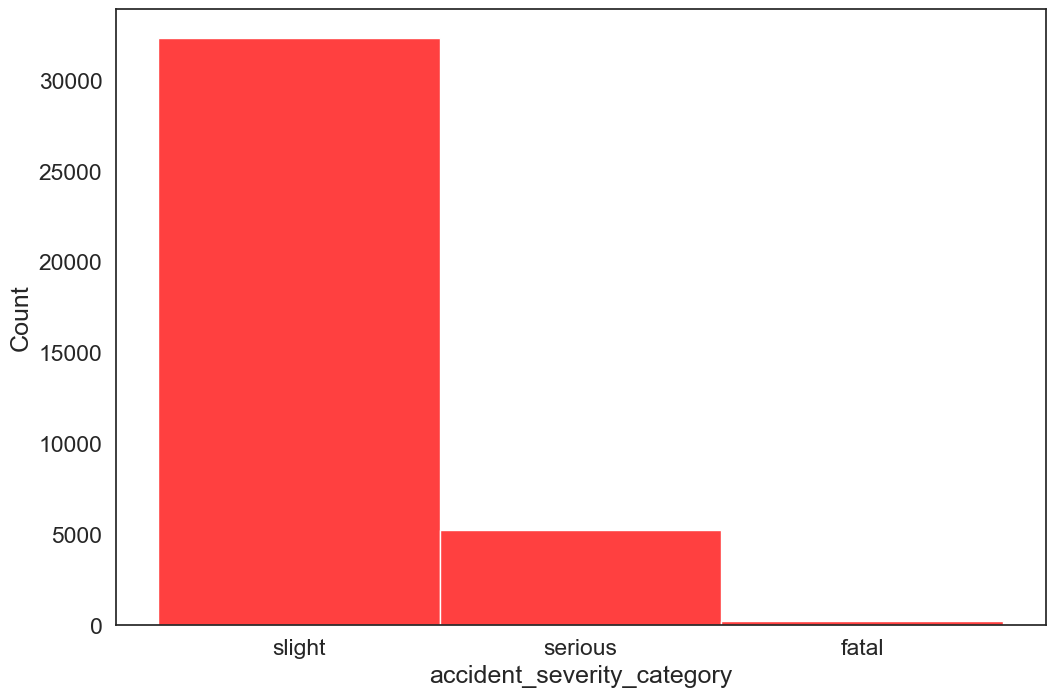

In [28]:
fatal   = len(df[df['accident_severity_category'] == 'fatal'])
serious = len(df[df['accident_severity_category'] == 'serious'])
slight  = len(df[df['accident_severity_category'] == 'slight'])

sns.histplot(data=df, x="accident_severity_category", color = 'Red')

print('Counts of slight cases = ', slight)
print('Counts of serious cases = ', serious)
print('Counts of fatal cases = ', fatal)

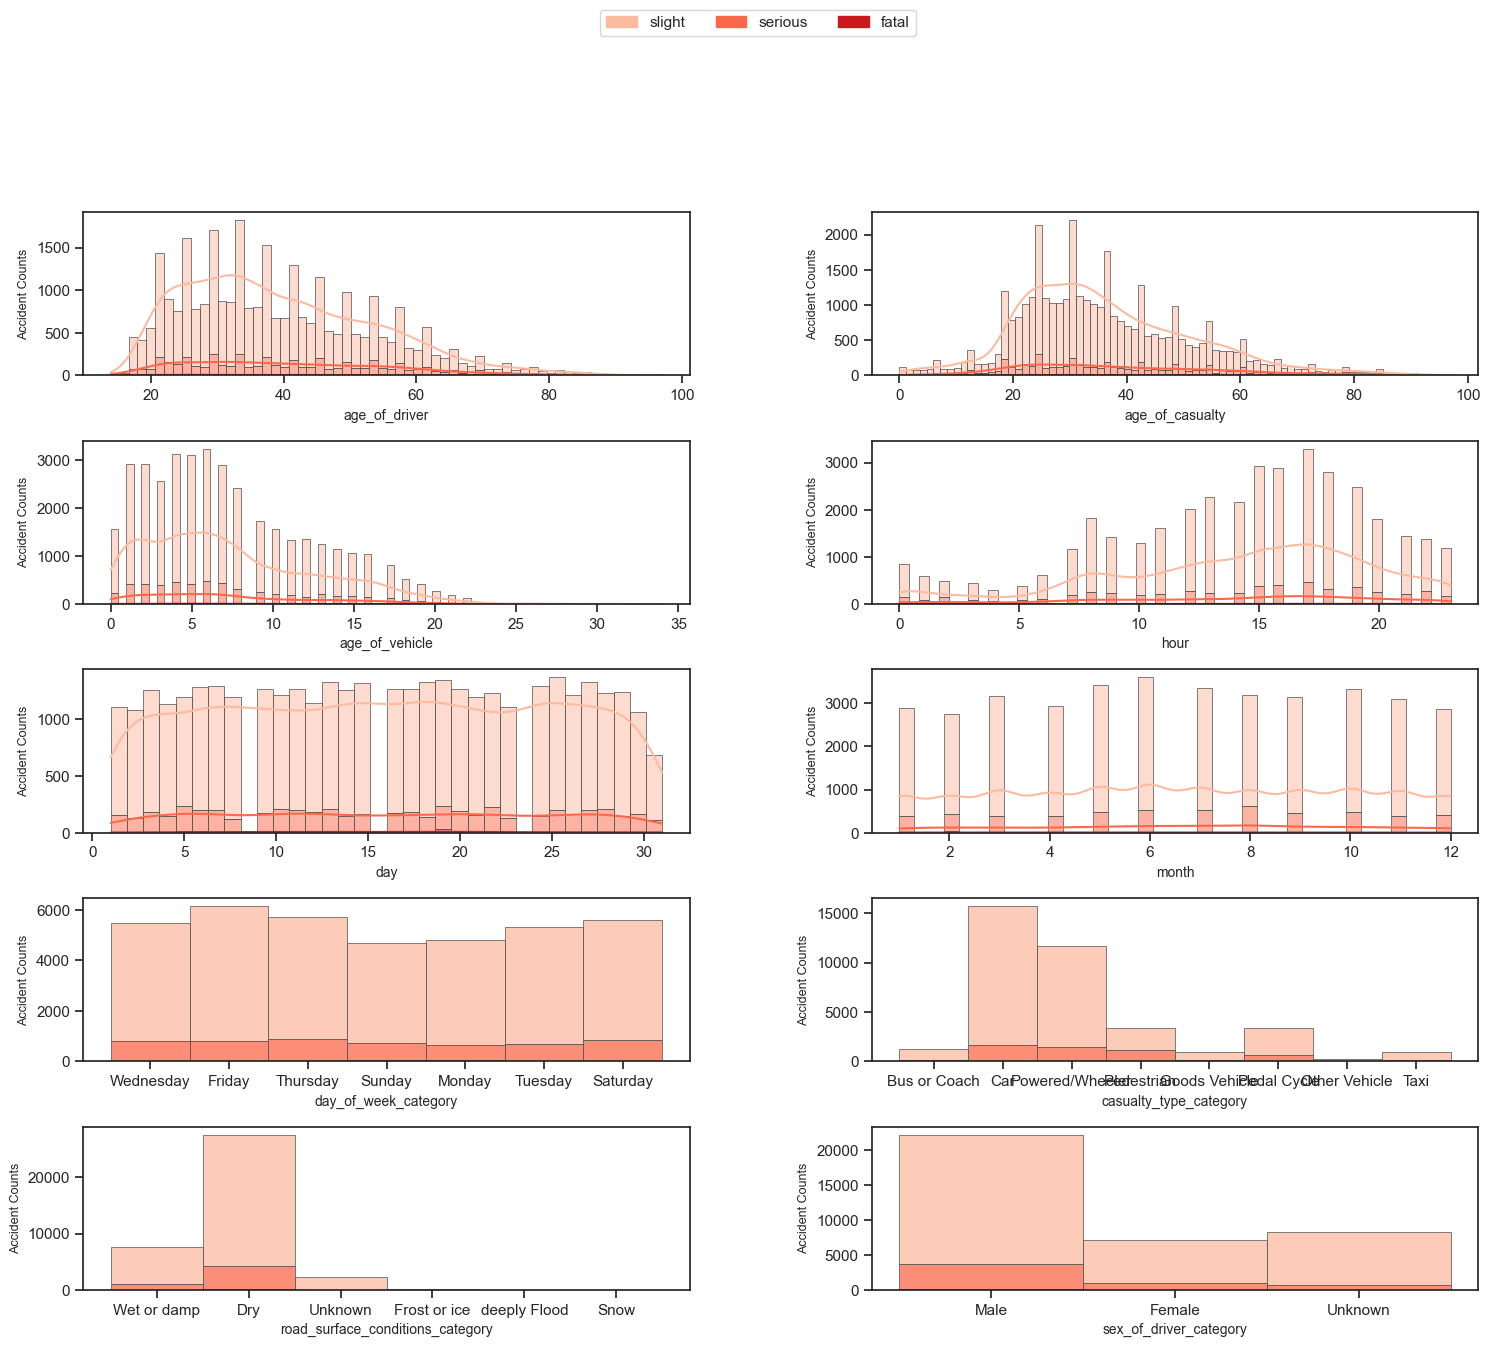

In [29]:
sns.set_theme(style="ticks")
categorical_vars = {
    "casualty_type_category",
    "day_of_week_category",
    "weather_conditions_category",
    "road_surface_conditions_category",
    "sex_of_driver_category"
}

severity_order = ["slight", "serious", "fatal"]
my_palette = sns.color_palette("Reds", n_colors=3)
fig = plt.figure(figsize=(18, 14))  # 宽度增加以容纳3列
gs = gridspec.GridSpec(5, 2, figure=fig, hspace=0.4, wspace=0.3)

vars_to_plot = [
    "age_of_driver",        
    "age_of_casualty", 
    "age_of_vehicle",
    "hour",
    "day",
    "month",
    "day_of_week_category",
    "casualty_type_category",
    "road_surface_conditions_category",
    "sex_of_driver_category"
]

for idx, var in enumerate(vars_to_plot):
    ax = fig.add_subplot(gs[idx])
    if var in categorical_vars:
        df_cat = df.copy()
        df_cat[var] = df_cat[var].astype(str)
        sns.histplot(
            data=df_cat,
            x=var,
            hue="accident_severity_category",
            hue_order=severity_order,    
            multiple="stack",
            discrete=True,
            palette=my_palette,
            edgecolor=".3",
            linewidth=0.5,
            ax=ax,
            legend=False
        )
        ax.set_xlabel(var, fontsize=10)
        ax.set_ylabel("Accident Counts", fontsize=9)
    else:
        data_to_plot = df.dropna(subset=[var])
        sns.histplot(
            data=data_to_plot,
            x=var,
            hue="accident_severity_category",
            hue_order=severity_order,
            multiple="stack",
            palette=my_palette,
            kde=True,
            edgecolor=".3",
            linewidth=0.5,
            ax=ax,
            legend=False
        )
        ax.set_xlabel(var, fontsize=10)
        ax.set_ylabel("Accident Counts", fontsize=9)
        ax.ticklabel_format(style='plain', axis='x', useOffset=False)
    ax.set_xticklabels(ax.get_xticklabels())

patches = [mpatches.Patch(color=my_palette[i], label=severity_order[i]) for i in range(3)]
fig.legend(handles=patches, loc='upper center', bbox_to_anchor=(0.5, 1.03), ncol=3)

plt.tight_layout() 
plt.show()


The analysis of time shows a noticeable peak occurring around **17:00**, which seems to indicate that late afternoon or early evening, particularly towards the rush hour, is a more dangerous period for traffic accidents.  Specifically, **Friday** stands out, as it has recorded the most incidents, with about 6,154 cases, making it the day with the highest number of accidents during the week.  The data suggests that most of the individuals involved in accidents are in the age group of **20 to 35** years.  Within this broad age group, it is noted that the highest number of casualties happen between the ages of **25** and **30**.  This may imply that the majority of traffic incidents occur with individuals in their active and potentially more prone to risk-taking years. Furthermore, a considerable portion of accidents seems to be linked to **car occupants**, and many of these accidents occur under typical, not very severe, conditions, which might not seem too risky initially.  **Male** drivers seem to be involved in these accidents at a higher frequency, which suggests that gender might play a role in the occurrence of traffic incidents.

Probability of different accident severities under various weather conditions:
accident_severity_category   fatal  serious  slight
weather_conditions_category                        
Fine and high winds          0.004    0.177   0.818
Fine no high winds           0.006    0.153   0.841
Fog or mist                  0.000    0.035   0.965
Other                        0.003    0.078   0.919
Raining and high winds       0.005    0.164   0.832
Raining no high winds        0.005    0.134   0.861
Snowing and high winds       0.000    0.250   0.750
Snowing no high winds        0.048    0.071   0.881
Unknown                      0.000    0.038   0.962


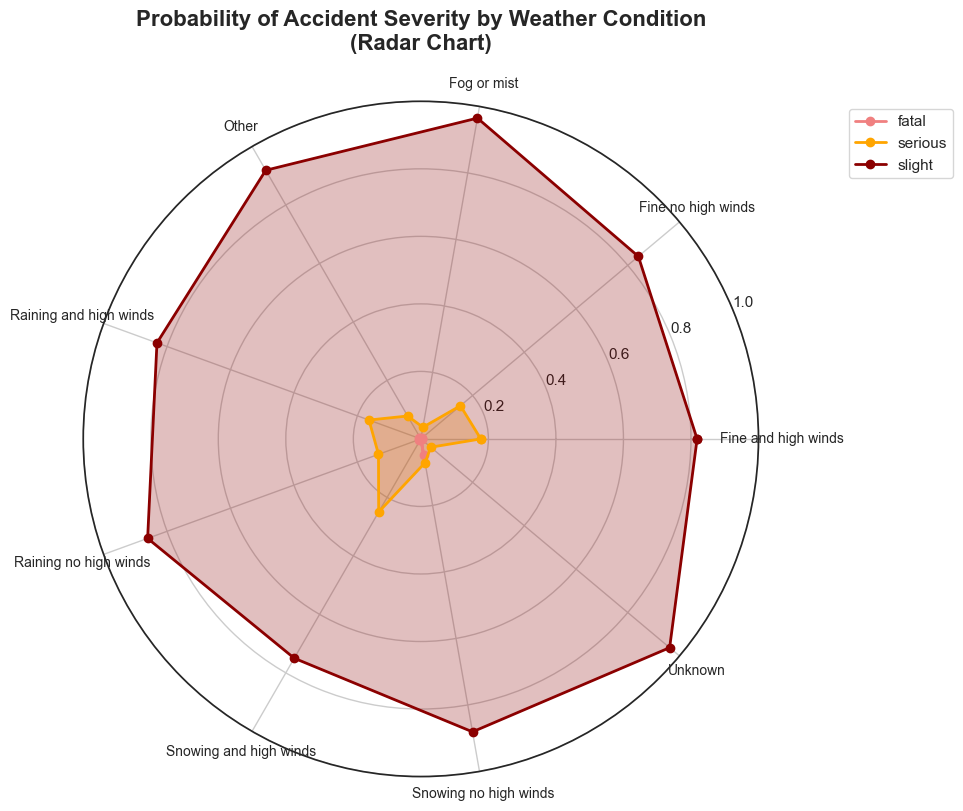

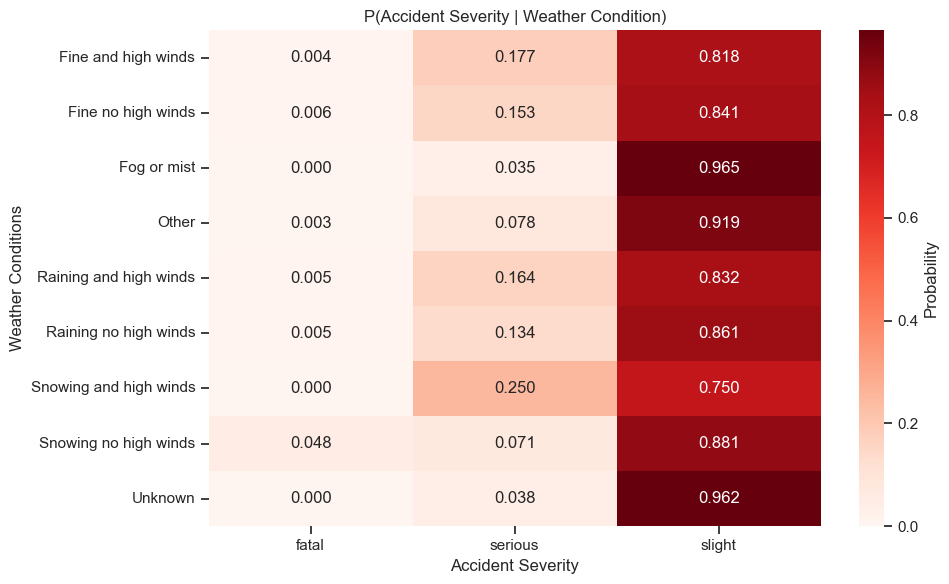


Probability of different weather conditions for each accident severity:
accident_severity_category   fatal  serious  slight
weather_conditions_category                        
Fine and high winds          0.005    0.008   0.006
Fine no high winds           0.850    0.831   0.742
Fog or mist                  0.000    0.000   0.002
Other                        0.024    0.027   0.051
Raining and high winds       0.005    0.007   0.006
Raining no high winds        0.107    0.107   0.112
Snowing and high winds       0.000    0.000   0.000
Snowing no high winds        0.010    0.001   0.001
Unknown                      0.000    0.020   0.080


In [30]:
# Calculate conditional probability: P(Severity|Weather Condition)
weather_severity_probs = pd.crosstab(df['weather_conditions_category'], 
                                   df['accident_severity_category'], 
                                   normalize='index')  # Normalize by row

print("Probability of different accident severities under various weather conditions:")
print(weather_severity_probs.round(3))
categories = weather_severity_probs.index.tolist()
severity_types = weather_severity_probs.columns.tolist()
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

# Number of variables
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  
colors = ['lightcoral', 'orange', 'darkred']
for i, severity in enumerate(severity_types):
    values = weather_severity_probs[severity].tolist()
    values += values[:1]  
    ax.plot(angles, values, 'o-', linewidth=2, label=severity, color=colors[i])
    ax.fill(angles, values, alpha=0.25, color=colors[i])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'])
ax.set_title('Probability of Accident Severity by Weather Condition\n(Radar Chart)', 
             size=16, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 6))
sns.heatmap(weather_severity_probs, annot=True, fmt='.3f', 
           cmap='Reds', cbar_kws={'label': 'Probability'})
plt.title('P(Accident Severity | Weather Condition)')
plt.ylabel('Weather Conditions')
plt.xlabel('Accident Severity')
plt.tight_layout()
plt.show()

# Reverse probability: P(Weather Condition|Severity)
severity_weather_probs = pd.crosstab(df['weather_conditions_category'], 
                                   df['accident_severity_category'], 
                                   normalize='columns')  # Normalize by column

print("\nProbability of different weather conditions for each accident severity:")
print(severity_weather_probs.round(3))

Most of accidents in different weather are slight accidents,counting for 80-95%, but there is distinct accident severity variance in different extreme weather: snowing and high winds weather causes more serious accidents wherease foggy weather causes less nasty accidents.

After carried out the descriptive statistics. We plotted the distribution of some key numeric columns and the count of accident cases in each borough to visualize the distribution of data more thoroughly.

**4.1.4.4 spatial distribution of accident severity**

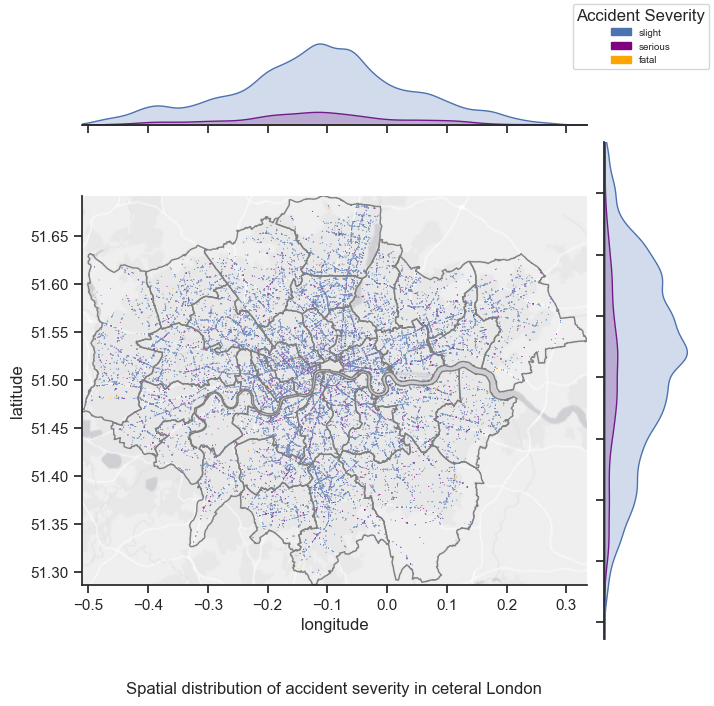

In [31]:
if df.crs is None:
    df.set_crs(epsg=4326, inplace=True)

boroughs = ward.to_crs(epsg=4326)
g = sns.jointplot(
    x='longitude',
    y='latitude',
    hue="accident_severity_category",
    palette=['b', 'purple', 'orange'],
    data=df,
    s=0.5,
    height=7
)

contextily.add_basemap(
    g.ax_joint,
    crs="EPSG:4326",
    source=contextily.providers.Esri.WorldGrayCanvas,
    attribution=False
)
boroughs.boundary.plot(ax=g.ax_joint, edgecolor='gray', linewidth=1)
g.ax_joint.legend_.remove()
handles = [
    mpatches.Patch(color='b', label='slight'),
    mpatches.Patch(color='purple', label='serious'),
    mpatches.Patch(color='orange', label='fatal')
]
g.fig.legend(
    handles=handles,
    loc='upper right',
    fontsize=7,
    title="Accident Severity"
)
plt.subplots_adjust(top=0.95)
minx, miny, maxx, maxy = boroughs.total_bounds
g.ax_joint.set_xlim(minx, maxx)
g.ax_joint.set_ylim(miny, maxy)
g.ax_joint.set_title('Spatial distribution of accident severity in ceteral London', loc='center', y=-0.3)
plt.show()

As illustrated in Figure, the majority of accidents are concentrated in inner London, particularly in locations such as Westminster, the City of London, and Islington. Conversely, fewer accidents occur in the suburban regions. This implies that the density of people and vehicles in bustling urban centres is a significant factor leading to a higher number of accidents than that in more tranquil suburban areas.

## 5. Methodology

[[ go back to the top ]](#Table-of-contents)

*[Note: a flow chart that describes the methodologies]*

![Flow chart 1](methodology_flowchart.png))

After we carrying out exploratory analysis on the dataset, we could obviously find out thta the datasets'classes of traffic accidents are non-uniformly distributed over the data space, namely, highly skewed distribution. Compared to power function model based on speed (Elvik, 2005), this report tend to use machine learning to explore multiple dimension risk independent variables without speed, which still can capture rhe structure characters of accident risk.

### 5.1 Difference in Difference

#### 5.1.1 Policy Context and Research Design

**Research Design:**
I construct a quasi-experimental framework using borough-level policy variation. Treatment groups represent areas experiencing policy changes around September 2023, enabling causal impact assessment of speed limit policies on accident severity patterns.

**Data Limitation:** Precise policy implementation timing varies by borough, requiring careful treatment group identification based on available policy documentation.

**Treatment and Control Group Definition**


Based on TfL's London Speed Limit Map analysis and 20mph zone coverage patterns, we define our treatment and control groups as follows:

**Treatment Group (Enhanced 20mph Enforcement Areas from September 2023):**

- Barking and Dagenham
- Havering  
- Newham
- Redbridge
- Hounslow
- Hillingdon
- Harrow
- Sutton
- Enfield

**Note**: Treatment group includes 9 outer London boroughs with limited 20mph coverage prior to September 2023, based on data availability in our traffic accident dataset.

**Control Group:** All remaining London boroughs after propensity score matching


**Rationale for Group Selection**

Treatment group selection uses TfL's speed limit mapping data, identifying boroughs with lower 20mph coverage prior to September 2023. This design leverages natural policy variation to compare newly enhanced enforcement areas against established zones, ensuring adequate pre-post periods for robust DID estimation.

**Data Source**: [TfL London Digital Speed Limit Map]('https://share.google/1KgyDlCqPzcGHw2T3')

$$
\mathrm{severity}_{b,t}
\;=\;
\alpha\cdot \mathrm{Open}_{b,t}
\;+\;
\gamma_b
\;+\;
\delta_t
\;+\;
\boldsymbol{\beta}'\,X_{b,t}
\;+\;
\varepsilon_{b,t}
$$

$$
 \gamma_b：Borough fixed effect;
 \delta_t：Months fixed effect;  
\boldsymbol{\beta}'\,X_{b,t}： any other influential factors
$$

#### 5.1.1 build model and present outcome

I will combine serious and fatal together not only because the minimal number of fatal category but the vague difference between them.

In [32]:
df['severity_binary'] = df['accident_severity_category'].replace({
    'slight': 'slight',
    'serious': 'severe',
    'fatal': 'severe'
})
df['severity_code'] = df['severity_binary'].map({'slight': 0, 'severe': 1})
label_order = ['slight', 'severe']

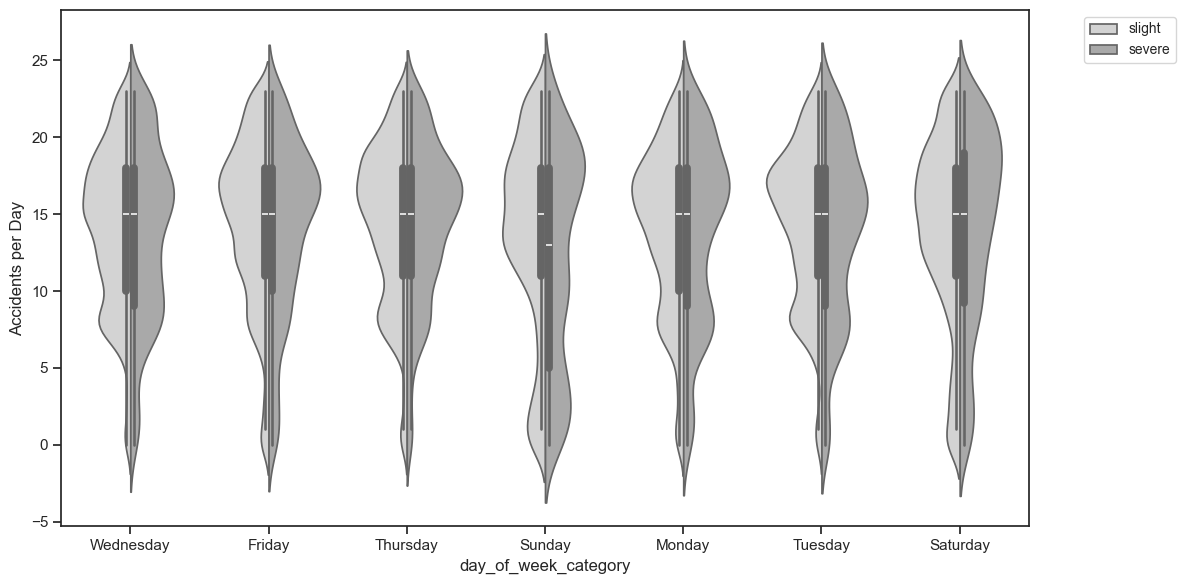

In [33]:
# Violin plot of accidents per day by severity
df_filtered = df[df['severity_binary'].isin(['slight', 'severe'])]
fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(data=df_filtered, x='day_of_week_category', y='hour', 
               hue='severity_binary', split=True, 
               palette={'slight': 'lightgray', 'severe': 'darkgray'}, ax=ax)
ax.set_ylabel('Accidents per Day')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()


Such violin chart demostrates the distripution of daily slight and severe accidents in a week. It's easy to find that there is no significant variance in weekdays and weekand. Moreover, the distribution of accident times no matter slight or severe throughout all weeks shows a similar bimodal pattern to some extend, mainly concentrated during the morning and evening rush hours but the evening has more frequent severe accidents which means there is some sort of diversity between accident severity and time.  Considering common sense of rush hour, I tend to put rush hour as a variable to discover.

In [34]:
print("Columns in df:", df.columns.tolist())
print("Unique areas:", df['Area'].unique()[:10])  # 替换实际列名

Columns in df: ['accident_severity', 'casualty_class', 'sex_of_casualty', 'age_of_casualty', 'date', 'time', 'day_of_week', 'accident_year', 'longitude', 'latitude', 'Code', 'Area', 'weather_conditions', 'light_conditions', 'road_surface_conditions', 'number_of_vehicles', 'number_of_casualties', 'sex_of_driver', 'age_of_driver', 'casualty_type', 'engine_capacity_cc', 'age_of_vehicle', 'Job density', 'geometry', 'hour', 'day', 'month', 'accident_severity_category', 'casualty_class_category', 'sex_of_casualty_category', 'sex_of_driver_category', 'casualty_type_category', 'day_of_week_category', 'weather_conditions_category', 'road_surface_conditions_category', 'vehicles_rate', 'casualties_rate', 'severity_binary', 'severity_code']
Unique areas: ['Kingston upon Thames' 'Croydon' 'Bromley' 'Hounslow' 'Ealing' 'Havering'
 'Hillingdon' 'Harrow' 'Brent' 'Barnet']


#### 5.1.2 Panel Regression Exercise
Before setting up a difference in differences design, we run a panel regression in which unemployment is the dependent variable and minimum wage is the independent variable. 

In [35]:
match_covs = [
    'Job density',
    'vehicles_rate',
    'casualties_rate',
    'age_of_vehicle',
    'age_of_driver',
    'engine_capacity_cc'
]

weather_dummies = pd.get_dummies(df['weather_conditions_category'], prefix='weather')
road_dummies    = pd.get_dummies(df['road_surface_conditions_category'],  prefix='road')
light_dummies   = pd.get_dummies(df['light_conditions'],                prefix='light')
cov_means = {c: 'mean' for c in match_covs}
cov_means.update({col: 'mean' for col in weather_dummies.columns})
cov_means.update({col: 'mean' for col in road_dummies.columns})
cov_means.update({col: 'mean' for col in light_dummies.columns})
cov_means['treat'] = 'first'  

In [36]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['Area','date','severity_code']).copy() 
treat_boros = [
 "Barking and Dagenham",
 "Havering",
 "Newham",
 "Redbridge",
 "Hounslow",
 "Hillingdon",
 "Harrow",
 "Sutton",
 "Enfield"
]
policy_day = pd.to_datetime("2023-09-01")


df_pre = df[df['date'] < policy_day].copy()
df_pre['month'] = df_pre['date'].dt.to_period('M')

weather_dummies = pd.get_dummies(
    df_pre['weather_conditions_category'], prefix='weather')
road_dummies    = pd.get_dummies(
    df_pre['road_surface_conditions_category'], prefix='road')
light_dummies   = pd.get_dummies(
    df_pre['light_conditions'], prefix='light')

df_cov = pd.concat(
    [df_pre, weather_dummies, road_dummies, light_dummies],
    axis=1
)
agg_map = {
    **{c:'mean' for c in match_covs},
    **{col:'mean' for col in weather_dummies.columns},
    **{col:'mean' for col in road_dummies.columns},
    **{col:'mean' for col in light_dummies.columns},
}
df_b = (
    df_cov
    .groupby(['Area','month'], as_index=False)
    .agg(agg_map)
)

#  treat
df_b['treat'] = df_b['Area'].isin(treat_boros).astype(int)

#  propensity score
ps_model = LogisticRegression(max_iter=1000)
X_ps = df_b[match_covs]
y_ps = df_b['treat']
ps_model.fit(X_ps, y_ps)
df_b['pscore'] = ps_model.predict_proba(X_ps)[:,1]

treated = df_b[df_b['treat']==1]
control = df_b[df_b['treat']==0]
nn = NearestNeighbors(n_neighbors=1).fit(control[['pscore']])
dist, idx = nn.kneighbors(treated[['pscore']])
caliper = 0.02
mask = dist.flatten() <= caliper
matched_treated = treated[mask].copy()
matched_control = control.iloc[idx.flatten()[mask]].copy()

control_boros = list(set(matched_control['Area'].tolist()) - set(treat_boros))

# —— 4. 构造匹配后全时段样本 df_matched —— 
selected_boros = treat_boros + control_boros
df_matched = df[df['Area'].isin(selected_boros)].copy()
df_matched['treat'] = df_matched['Area'].isin(treat_boros).astype(int)
df_matched['post']  = (df_matched['date'] >= policy_day).astype(int)
df_matched['did']   = df_matched['treat'] * df_matched['post']

<Axes: xlabel='week'>

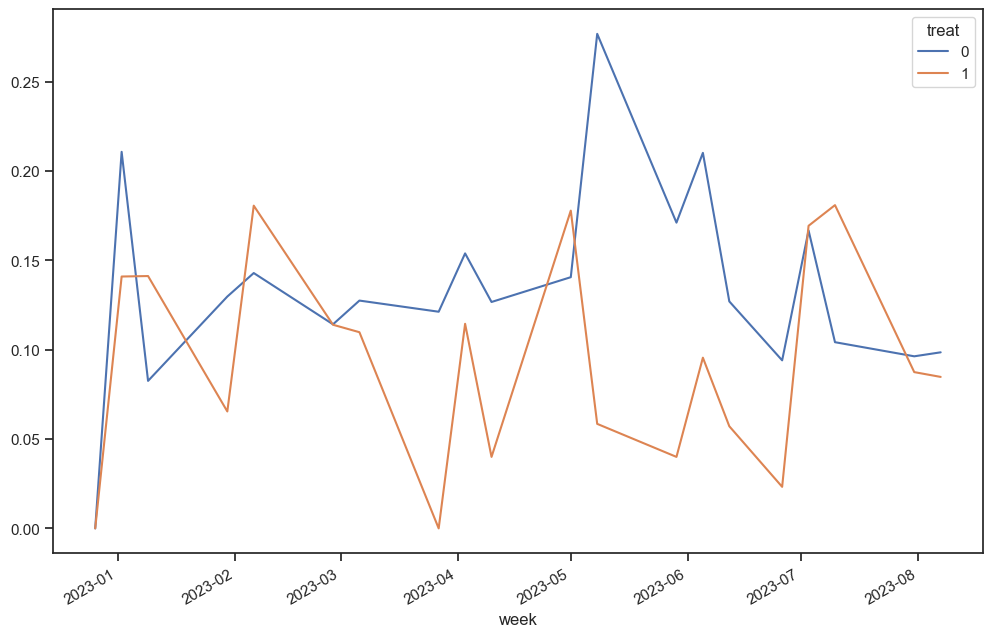

In [37]:
df_pre = df_matched[df_matched['date'] < policy_day]
df_pre['week'] = df_pre['date'].dt.to_period('W').dt.start_time
weekly_pre = df_pre.groupby(['week','treat'])['severity_code'].mean().unstack('treat')
weekly_pre.plot()

From the output, It's not hard to figure out that it's not parallel from 2023-01 to 2023-04 which sometimes caused contrary tendency. From that case, the key is compressing timeframe and choosing parallel one before policy time what would be 2023-04 to 2023-09.

In [38]:
analysis_start = pd.to_datetime("2023-04-01")
df_final = df_matched[df_matched['date'] >= analysis_start].copy()

print(f"Analysis sample: {len(df_final)} observations")
print(f"Time range: {df_final['date'].min()} to {df_final['date'].max()}")

# Redefine post-policy indicator
df_final['post'] = (df_final['date'] >= policy_day).astype(int)
df_final['did'] = df_final['treat'] * df_final['post']

# Final DID regression with time trend controls
final_formula = """severity_code ~ did + treat + post + month +  
                   hour + number_of_vehicles + casualties_rate"""

mod_final = smf.ols(final_formula, data=df_final).fit()

print(f"\n=== MAIN DID RESULTS ===")
print(f"DID coefficient: {mod_final.params['did']:.4f}")
print(f"Standard error: {mod_final.bse['did']:.4f}")
print(f"p-value: {mod_final.pvalues['did']:.4f}")
print(f"95% confidence interval: [{mod_final.conf_int().loc['did', 0]:.4f}, {mod_final.conf_int().loc['did', 1]:.4f}]")

# Statistical significance assessment
if mod_final.pvalues['did'] < 0.05:
    print("Result: Statistically significant (p < 0.05)")
elif mod_final.pvalues['did'] < 0.10:
    print("Result: Marginally significant (p < 0.10)")
else:
    print("Result: Not significant (p ≥ 0.10)")

# Effect size interpretation
effect_size = mod_final.params['did']
baseline_severity = df_final[df_final['treat']==1]['severity_code'].mean()
relative_effect = (effect_size / baseline_severity) * 100

print(f"\n=== EFFECT SIZE INTERPRETATION ===")
print(f"Baseline severity score: {baseline_severity:.3f}")
print(f"Absolute effect: {effect_size:.4f} points")
print(f"Relative effect: {relative_effect:.1f}%")

Analysis sample: 9392 observations
Time range: 2023-04-01 00:00:00 to 2023-12-12 00:00:00

=== MAIN DID RESULTS ===
DID coefficient: 0.0414
Standard error: 0.0155
p-value: 0.0076
95% confidence interval: [0.0110, 0.0717]
Result: Statistically significant (p < 0.05)

=== EFFECT SIZE INTERPRETATION ===
Baseline severity score: 0.124
Absolute effect: 0.0414 points
Relative effect: 33.5%


Period: 2023-04-01 00:00:00 to 2023-12-12 00:00:00
Total: 9392 | Slight: 8026 | Severe: 1366


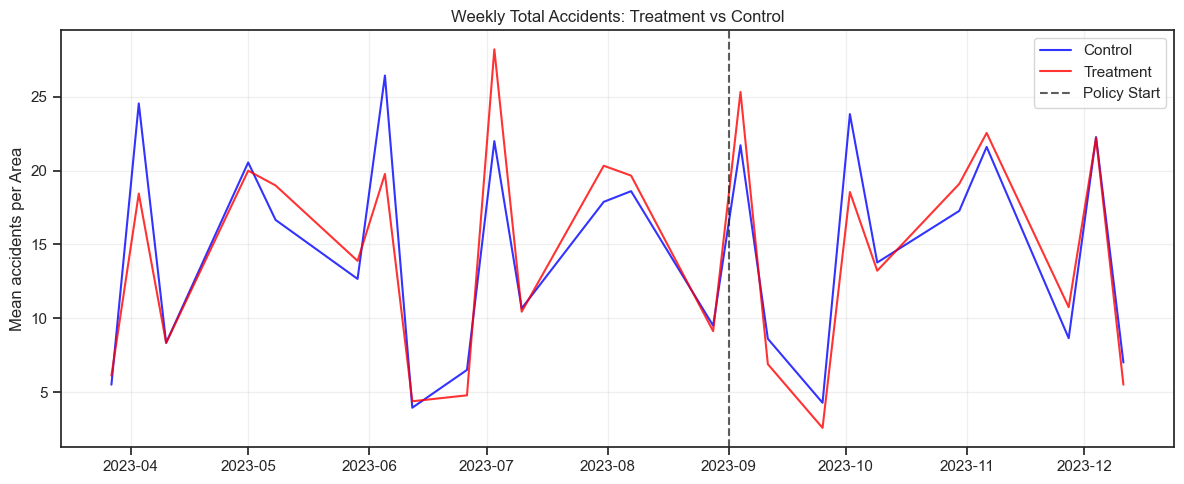

DID on total accidents (Poisson): coef=-0.0143, p=0.8625, CI=[-0.1758, 0.1473]


In [40]:
df_matched = df_matched.rename(columns={'Job density': 'job_density'})
df_analysis = df_matched[df_matched['date'] >= pd.to_datetime("2023-04-01")].copy()
df_analysis['post'] = (df_analysis['date'] >= policy_day).astype(int)
df_analysis['did'] = df_analysis['treat'] * df_analysis['post']
df_analysis['week'] = df_analysis['date'].dt.to_period('W').dt.start_time
df_analysis['is_slight'] = (df_analysis['accident_severity_category'] == 'slight').astype(int)
df_analysis['is_severe'] = (df_analysis['accident_severity_category'].isin(['serious', 'fatal'])).astype(int)

print(f"Period: {df_analysis['date'].min()} to {df_analysis['date'].max()}")
print(f"Total: {len(df_analysis)} | Slight: {df_analysis['is_slight'].sum()} | Severe: {df_analysis['is_severe'].sum()}")

agg = (df_analysis
       .groupby(['Area','week','treat','post'], as_index=False)
       .size()
       .rename(columns={'size':'total'}))
agg['did'] = agg['treat'] * agg['post']

# 2) 单图：Treatment vs Control 的周总事故数
fig, ax = plt.subplots(figsize=(12,5))
for tval, color, label in [(0,'blue','Control'), (1,'red','Treatment')]:
    s = (agg[agg['treat']==tval]
         .groupby('week')['total'].mean())
    ax.plot(s.index, s.values, color=color, label=label, alpha=0.8)
ax.axvline(policy_day, ls='--', c='k', alpha=0.7, label='Policy Start')
ax.set_title('Weekly Total Accidents: Treatment vs Control')
ax.set_ylabel('Mean accidents per Area')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# 3) Poisson DID（带双向固定效应，Area 聚类稳健方差）
import statsmodels.api as sm
po = sm.GLM.from_formula(
    'total ~ treat + post + did + C(Area) + C(week)',
    data=agg, family=sm.families.Poisson()
).fit(cov_type='cluster', cov_kwds={'groups': agg['Area']})

did_coef = po.params['did']; did_p = po.pvalues['did']
ci_low, ci_high = po.conf_int().loc['did']
print(f'DID on total accidents (Poisson): coef={did_coef:.4f}, p={did_p:.4f}, CI=[{ci_low:.4f}, {ci_high:.4f}]')

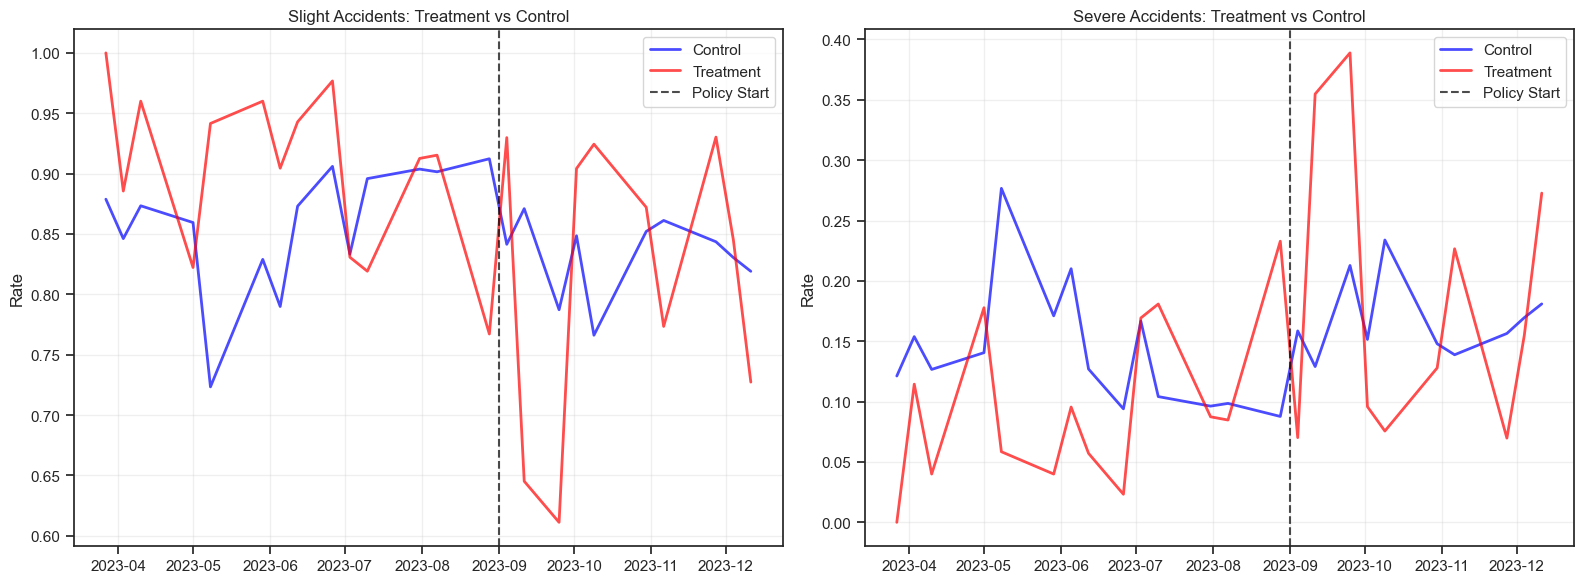


Slight: Coef=-0.0344, p=0.0192**, CI=[-0.0632, -0.0056]

Severe: Coef=0.0344, p=0.0192**, CI=[0.0056, 0.0632]

=== RESULTS SUMMARY ===
Type       Coefficient  P-value    Significant 
--------------------------------------------------
Slight     -0.0344      0.0192     Yes         
Severe     0.0344       0.0192     Yes         

=== POLICY IMPACT ===
• Slight: Policy significantly decreased accident probability
• Severe: Policy significantly increased accident probability
• Differential effect (Severe-Slight): 0.0688


In [41]:
# Parallel trends visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for outcome, ax, title in [('is_slight', axes[0], 'Slight Accidents'), 
                          ('is_severe', axes[1], 'Severe Accidents')]:
    for treat_val, color, label in [(0, 'blue', 'Control'), (1, 'red', 'Treatment')]:
        weekly_data = (df_analysis[df_analysis['treat'] == treat_val]
                      .groupby('week')[outcome].mean())
        ax.plot(weekly_data.index, weekly_data.values, 
               color=color, label=label, alpha=0.7, linewidth=2)
    
    ax.axvline(policy_day, linestyle='--', color='black', alpha=0.7, label='Policy Start')
    ax.set_title(f'{title}: Treatment vs Control')
    ax.set_ylabel('Rate')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# DID Regression
formula_base = "outcome ~ did + hour + job_density +  vehicles_rate + casualties_rate + age_of_vehicle + age_of_driver + engine_capacity_cc + C(Area)"
results = {}

for acc_type, outcome_var, desc in [('slight', 'is_slight', 'Slight'), ('severe', 'is_severe', 'Severe')]:
    formula = formula_base.replace('outcome', outcome_var)
    mod = smf.ols(formula, data=df_analysis).fit()
    
    coef = mod.params['did']
    pval = mod.pvalues['did']
    ci = mod.conf_int().loc['did']
    
    results[acc_type] = {'coef': coef, 'pval': pval, 'ci': ci}
    
    sig = "***" if pval < 0.01 else "**" if pval < 0.05 else "*" if pval < 0.1 else ""
    print(f"\n{desc}: Coef={coef:.4f}, p={pval:.4f}{sig}, CI=[{ci[0]:.4f}, {ci[1]:.4f}]")

# Summary
print(f"\n=== RESULTS SUMMARY ===")
print(f"{'Type':<10} {'Coefficient':<12} {'P-value':<10} {'Significant':<12}")
print("-" * 50)
for acc_type in ['slight', 'severe']:
    coef = results[acc_type]['coef']
    pval = results[acc_type]['pval']
    sig = "Yes" if pval < 0.1 else "No"
    print(f"{acc_type.title():<10} {coef:<12.4f} {pval:<10.4f} {sig:<12}")

# Interpretation
print(f"\n=== POLICY IMPACT ===")
for acc_type in ['slight', 'severe']:
    coef = results[acc_type]['coef']
    pval = results[acc_type]['pval']
    if pval < 0.1:
        direction = "increased" if coef > 0 else "decreased"
        print(f"• {acc_type.title()}: Policy significantly {direction} accident probability")
    else:
        print(f"• {acc_type.title()}: No significant effect detected")

effect_diff = results['severe']['coef'] - results['slight']['coef']
print(f"• Differential effect (Severe-Slight): {effect_diff:.4f}")

Even though policy has no significant influence on total accidents, but it surely impacts the structure of accidents' severity. More detailed, this policy prone to decrease slight accident occurances but rise severe accidents which may due to driver behaviors' change and so on.

Based on above information, it's easy to figure out that policy significantly influent the direction of accident severity which may cause noise if combien the data before and after policy together. So choosing timeframe after policy date 2023-09-01 to do regression to see key indicators to affect accident severity.

### 5.2 Machine Learning

#### 5.2.1 model design

In [42]:
df= df_matched[df_matched['date'] >= pd.to_datetime("2023-09-01")].copy()
df['rush_hour'] = ((df['hour'] >= 7) & (df['hour'] <= 9)).astype(int) + \
                  ((df['hour'] >= 16) & (df['hour'] <= 19)).astype(int)
df['rush_hour'] = (df['rush_hour'] > 0).astype(int)
df['extreme_age'] = ((df['age_of_driver'] <= 25) | (df['age_of_driver'] >= 65)).astype(int)
df['rush_hour'] = df['rush_hour'].map({0: 'Non-rush', 1: 'Rush'})
df['extreme_age'] = df['extreme_age'].map({0: 'Normal_age', 1: 'Extreme_age'})

numeric_features = [
    'age_of_vehicle','job_density', 
    'vehicles_rate', 'casualties_rate', 
]


categorical_features = [
    'weather_conditions_category','rush_hour','extreme_age',
    'road_surface_conditions_category',
    'day_of_week_category',
    'casualty_type_category',
    'sex_of_driver_category'
]

# remove unknown lables
for col in categorical_features:
    df = df[~df[col].str.contains("Unknown", na=False)]
    df = df[~df[col].str.contains("Unknown", na=False)]
    df = df[~df[col].str.contains("Unknown", na=False)]

X = df[numeric_features + categorical_features]
y = df['severity_code']

#preprocess the datasets
numeric_tf = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('sc',  StandardScaler())
])

categorical_tf = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('oh',  OneHotEncoder(handle_unknown='ignore'))
])

pre = ColumnTransformer([
    ('num', numeric_tf, numeric_features),
    ('cat', categorical_tf, categorical_features)
])

#classify the model
logreg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    solver='lbfgs'
)

clf = Pipeline([
    ('pre', pre),
    ('model', logreg)
])

# split train dataset and test dataset
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

clf.fit(X_tr, y_tr)

,steps,"[('pre', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [43]:
# Get the preprocessor and the model
preprocessor = clf.named_steps['pre']
model = clf.named_steps['model']

# Use transform to get the variables after processing
X_te_transformed = preprocessor.transform(X_te)
feature_names = preprocessor.get_feature_names_out()

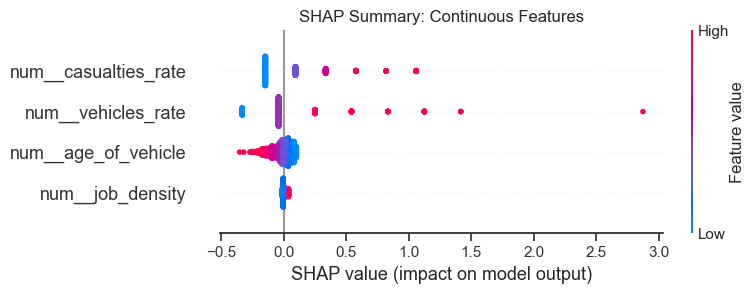

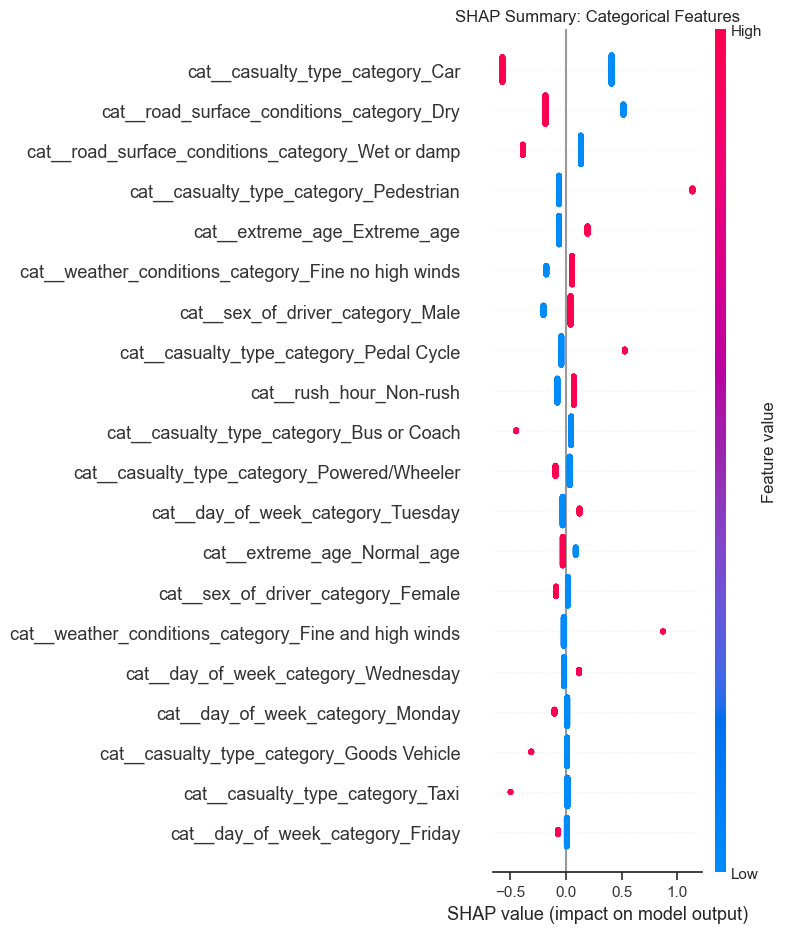

In [44]:
explainer = shap.LinearExplainer(model, X_te_transformed, feature_perturbation="interventional")
shap_values_all = explainer.shap_values(X_te_transformed[:1000])
all_names = list(feature_names)

# split continuous and categories variables
num_idx = []
for i, name in enumerate(all_names):
    if any(name.startswith(f"num__{col}") for col in numeric_features):
        num_idx.append(i)
cat_idx = [i for i in range(len(all_names)) if i not in num_idx]

# continuous variables' SHAP summary plot
shap.summary_plot(
    np.array(shap_values_all)[:, num_idx],        # shap values for numeric
    X_te_transformed[:1000, num_idx],             # feature matrix
    feature_names=[all_names[i] for i in num_idx],
    show=False
)
plt.title("SHAP Summary: Continuous Features")
plt.tight_layout()
plt.show()

shap.summary_plot(
    np.array(shap_values_all)[:, cat_idx],        # shap values for categorical
    X_te_transformed[:1000, cat_idx],             # feature matrix
    feature_names=[all_names[i] for i in cat_idx],
    show=False
)
plt.title("SHAP Summary: Categorical Features")
plt.tight_layout()
plt.show()


#### 5.2.3 Model Performance Validation

              precision    recall  f1-score   support

      slight      0.907     0.684     0.780       753
      severe      0.320     0.679     0.435       165

    accuracy                          0.683       918
   macro avg      0.613     0.681     0.607       918
weighted avg      0.801     0.683     0.718       918



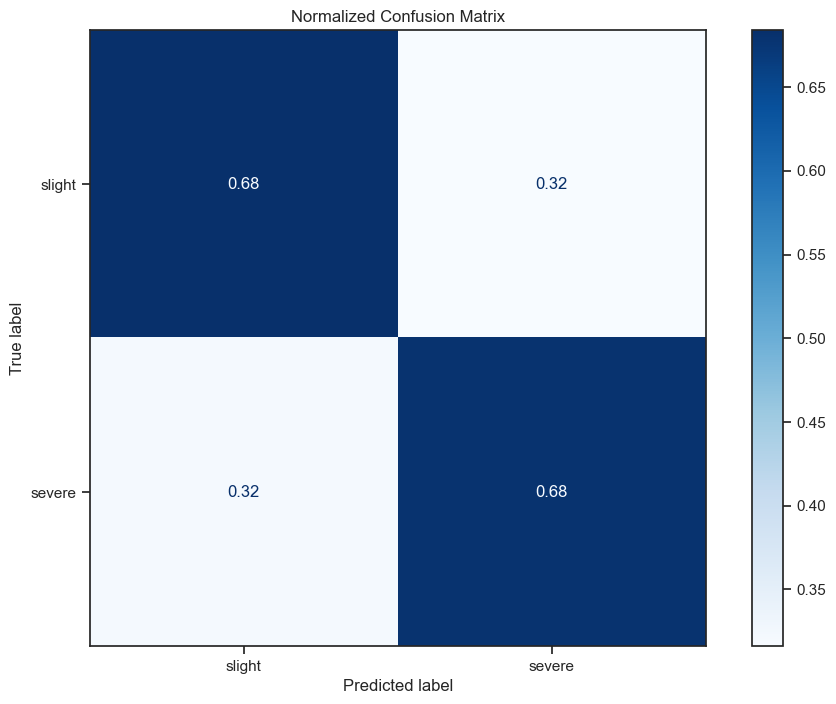

Binary ROC-AUC = 0.743


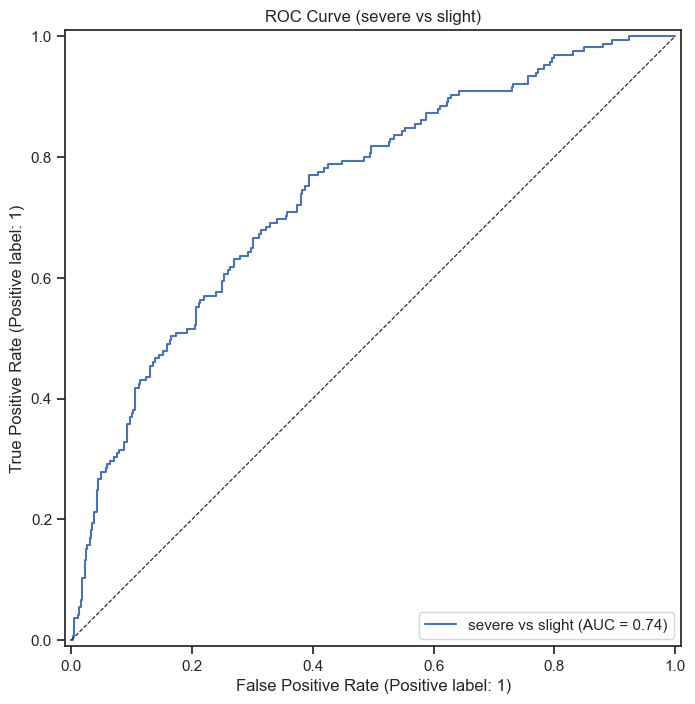

In [45]:
# get assessment report
y_pred = clf.predict(X_te)
print(classification_report(y_te, y_pred, target_names=label_order, digits=3))

# confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_te, y_pred,
    display_labels=label_order,
    cmap='Blues',
    normalize='true'
)
plt.title("Normalized Confusion Matrix"); plt.show()

# get ROC-AUC line
y_proba = clf.predict_proba(X_te)
auc = roc_auc_score(y_te, y_proba[:, 1])
print(f"Binary ROC-AUC = {auc:.3f}")

RocCurveDisplay.from_predictions(
    y_te, y_proba[:, 1],
    name='severe vs slight'
)
plt.plot([0, 1], [0, 1], 'k--', lw=0.8)
plt.title("ROC Curve (severe vs slight)"); plt.show()

Accuracy of logistic regression is **67%**, AUC is **0.71**. Recall for severe cases is quite high (0.647).
Pedestrian casuals, snow and adverse weather are significant predictors of severe accidents. Thus, the model explaining environmental and vulnerability risk factors is robust.

## 6. Conclusion

[[ go back to the top ]](#Table-of-contents)

My analysis used two methodologies combining Difference-in-Differences (DID) and Machine Learning to dig into London road accident severity patterns and policy impacts.


### 6.1 Policy Impact Assessment

The 20mph policy showed statistically significant effects on accident severity composition:
- Slight accidents decreased by 3.44% (p=0.019)
- Severe accidents increased by 3.44% (p=0.019)
- Total accident count unchanged (p=0.86)

 The policy caused a structural shift in accident severity rather than reducing overall frequency confirming the policy's primary effect is severity redistribution, not accident prevention.

### 6.2 Machine Learning Insights (AUC=0.7)
From the analysis of SHAP, the top key for the severity of accidents in this model is casualty rate which is the strongest indicator,then car attendence, temporary factors and road conditions as well as weather conditions. From human demensions, Pedestrains and people with pedal cycle who is fragile to some extent with High casualties rate are more prone to have severe accidents. Plus, female tend to have subtle less severe accident compared to male and people in extreme age are more tend to take risks and cause accidents. From vehicle dimension, the higher quantity the car is, the more severe accident is. Whereas, cars including bus or coach is less likely to have strong severity of accidents.  From temperory factor, peak time (7am-9am and 4pm-7pm) effect is limited compared to off-peak time aligned with Violin chart output,which means most cases of rush hours is slight even though the quantity in this timeframe is giant, proving collisions tend to occur at off-peak time. As for weather and environment conditions, bad weather conditions like raining day would increase accident severity. For Road dimension,  Adverse road surface conditions (wet or damp) increase risk, while dry surfaces conditions reduce severity probability. Last but not least, job density in each borough do have something to do with accident occurance positively.

### 6.3 Key Finding

The 20mph policy failed to reduce accident frequency but significantly altered severity distribution. While total accidents remained unchanged, the policy increased severe accident probability by 3.44% while decreasing slight accidents by the same magnitude. This structural shift suggests the policy may have unintended consequences on driver behavior that elevate accident severity without deterring accidents overall.

### 6.4 Limitation
**1. lack specific policy implemation time.**

**2. Sample number limited.**

**3. Complementary variable problem.** 


## References

[[ go back to the top ]](#Table-of-contents)

Department for Transport. (2023). Reported road casualties in Great Britain: Provisional results 2022. GOV.UK. https://www.gov.uk/government/statistics/reported-road-casualties-great-britain-provisional-results-2022/reported-road-casualties-great-britain-provisional-results-2022

Massie, D. L. (1993). Analysis of accident rates by age, gender, and time of day based on the 1990 Nationwide personal transportation survey. Final report.

Cullen, P., Möller, H., Woodward, M., Senserrick, T., Boufous, S., Rogers, K., ... & Ivers, R. (2021). Are there sex differences in crash and crash-related injury between men and women? A 13-year cohort study of young drivers in Australia. SSM-population health, 14, 100816.

Prieto-Rodriguez, J., Perez-Villadoniga, M. J., Salas, R., & Russo, A. (2022). Impact of London toxicity charge and ultra low emission zone on NO2. Transport Policy, 129, 237-247.

Fichera, E., Beshir, H., & Serna-Castaño, A. (2023). Low Emission Zones improve air quality, physical health and mental well-being. Institute for Policy Research, University of Bath. https://www.bath.ac.uk/publications/low-emission-zones-improve-air-quality-physical-health-and-mentalwell-being/attachments/Low_Emission_Zones_improve_air_quality__physical_health_and_mental_well-being.pdf .

Phan, D. C., & Truong, L. T. (2024). Traffic congestion and safety: mixed effects on total and fatal crashes. Sustainability, 16(20), 8911.

Regev, S., Rolison, J. J., & Moutari, S. (2018). Crash risk by driver age, gender, and time of day using a new exposure methodology. Journal of safety research, 66, 131-140.

Lee, D., Guldmann, J. M., & von Rabenau, B. (2023). Impact of Driver's Age and Gender, Built Environment, and Road Conditions on Crash Severity: A Logit Modeling Approach. International journal of environmental research and public health, 20(3), 2338. https://doi.org/10.3390/ijerph20032338

Obasi, I. C., & Benson, C. (2023). Evaluating the effectiveness of machine learning techniques in forecasting the severity of traffic accidents. Heliyon, 9(8), e18812. https://doi.org/10.1016/j.heliyon.2023.e18812

Sufian, M. A., Varadarajan, J., & Niu, M. (2024). RETRACTED: Enhancing prediction and analysis of UK road traffic accident severity using AI: Integration of machine learning, econometric techniques, and time series forecasting in public health research. Heliyon, 10(7).

Elvik, R. (2005). Speed and Road Safety: Synthesis of Evidence from Evaluation Studies. Transportation Research Record, 1908(1), 59–69. https://doi.org/10.1177/0361198105190800108 .